In [5]:
from skimage.measure import label, regionprops, regionprops_table
from skimage.morphology import binary_dilation
from skimage.transform import rotate
import os
import numpy as np
import matplotlib.pyplot as plt
import pathlib

import numpy as np
import tifffile as tiff
from skimage.transform import resize
from skimage import util
from skimage.io import imread
from skimage.filters import  threshold_triangle, median
from skimage.exposure import adjust_gamma
from skimage.measure import label,  regionprops_table
from skimage.morphology import remove_small_holes,  disk, remove_small_objects 
from skimage import exposure, feature
from skimage.filters import sobel

from skimage.measure import label, regionprops, moments_central
from scipy.ndimage import rotate, binary_dilation
from skimage.draw import polygon
import tifffile
from skimage.morphology import remove_small_holes, remove_small_objects, binary_closing, disk, reconstruction, binary_erosion
from skimage.segmentation import clear_border
from pathlib import Path
import numpy as np
import tifffile as tiff

In [6]:
def central_rect_from_mask(mask, angle_deg, width_frac=0.92, min_run_frac=0.25):
    """
    Returns central rectangle corners (x,y) in original image coords,
    excluding necks by keeping only the band where cross-section width is near-max.

    width_frac: keep rows whose width >= width_frac * max_width
    min_run_frac: minimum run length (fraction of device length) to accept
    """
    # rotate so device is axis-aligned; rotate uses CCW degrees
    m = rotate(mask.astype(float), -angle_deg, order=0) > 0.5

    H, W = m.shape
    rows = np.where(m.any(axis=1))[0]
    if rows.size == 0:
        return None

    y0, y1 = rows[0], rows[-1]
    band = m[y0:y1+1]

    # per-row left/right edges and width
    any_row = band.any(axis=1)
    x_left  = np.full(band.shape[0], np.nan, dtype=float)
    x_right = np.full(band.shape[0], np.nan, dtype=float)

    rr = np.where(any_row)[0]
    cols = np.argmax(band[rr], axis=1)
    x_left[rr] = cols
    x_right[rr] = band.shape[1] - 1 - np.argmax(band[rr, ::-1], axis=1)

    widths = x_right - x_left
    maxw = np.nanmax(widths)
    keep = widths >= (width_frac * maxw)

    # find longest contiguous run of keep==True
    k = keep.astype(np.int8)
    d = np.diff(np.r_[0, k, 0])
    starts = np.where(d == 1)[0]
    ends   = np.where(d == -1)[0]
    if starts.size == 0:
        return None

    run_lengths = ends - starts
    best = np.argmax(run_lengths)
    s, e = starts[best], ends[best]

    # enforce minimum run length (optional)
    if run_lengths[best] < min_run_frac * (y1 - y0 + 1):
        # fallback: just take central third
        mid = (y1 - y0 + 1) // 2
        half = int(0.15 * (y1 - y0 + 1))
        s, e = max(0, mid - half), min(band.shape[0], mid + half)

    # rectangle bounds in rotated coords
    y_top = y0 + s
    y_bot = y0 + (e - 1)
    xl = np.nanmedian(x_left[s:e])
    xr = np.nanmedian(x_right[s:e])

    corners_rot = np.array([
        [xl, y_top],
        [xr, y_top],
        [xr, y_bot],
        [xl, y_bot],
    ], dtype=np.float32)

    # rotate corners back to original coords
    cy, cx = (H - 1) / 2.0, (W - 1) / 2.0
    theta = np.deg2rad(angle_deg)
    R = np.array([[ np.cos(theta), -np.sin(theta)],
                  [ np.sin(theta),  np.cos(theta)]], dtype=np.float32)

    # note: corners are (x,y). convert to centered (x-cx, y-cy), rotate, shift back
    XY = corners_rot - np.array([cx, cy], dtype=np.float32)
    XY2 = (R @ XY.T).T + np.array([cx, cy], dtype=np.float32)

    return XY2  # (4,2) corners in original image coords (x,y)

In [13]:
def touches_border(mask: np.ndarray) -> bool:
    mask = mask.astype(bool)
    return (
        mask[0, :].any() or mask[-1, :].any() or
        mask[:, 0].any() or mask[:, -1].any()
    )

In [10]:
unseen_image_folder = Path(r"Z:\Bel\Vascumap_Example_Lifs\training_data\downsampled_4\in_focus_each_point")
tif_files = list(unseen_image_folder.glob("*.tif"))
print(len(tif_files))

j = 20
print(tif_files[j])


181
Z:\Bel\Vascumap_Example_Lifs\training_data\downsampled_4\in_focus_each_point\Defne_placenta_270325_Dexa2_Device_4_PROJECTION.tif


In [17]:

img = imread(tif_files[j]).astype(np.float32)

print(img.max(), img.min())
def signed_orientation(region):
    img = region.image.astype(float)
    mu = moments_central(img)
    y20 = mu[2, 0]
    y02 = mu[0, 2]
    y11 = mu[1, 1]
    angle_rad = 0.5 * np.arctan2(2 * y11, y20 - y02)
    return np.rad2deg(angle_rad)

median_img = median(img, footprint=disk(7))   # try disk(1..3)

sobel_img = sobel(median_img)
adjusted = adjust_gamma((median_img), gamma=0.7, gain=1)

image_x = img.shape[0]
image_y = img.shape[1]

sobel_adjusted = sobel(adjusted)
thresh = threshold_triangle(sobel_adjusted)
binary = sobel_adjusted > thresh
binary[int(3*image_x/8):int(5*image_x/8), int(3*image_y/8):int(5*image_y/8)] = 0

labels = label(binary)

data = regionprops_table(labels, binary, properties=("label", "area", "eccentricity"))  
condition = (data['area'] > 100) & (data['area'] < 30000) & (data['eccentricity'] > 0.5)
labels_to_dilate = util.map_array(labels, data['label'], data['label'] * condition)

dilated_output = np.zeros_like(labels, dtype=np.uint8)

selem_sizes = [31,  91, 121]

device_mask = None
corners = None
chosen_selem_size = None

for selem_size in selem_sizes:
    # IMPORTANT: reset dilated_output each attempt
    dilated_output = np.zeros_like(labels, dtype=np.uint8)

    for region in regionprops(labels_to_dilate):
        region_label = region.label
        mask = (labels_to_dilate == region_label)
        if not mask.any():
            continue

        angle_to_rotate = signed_orientation(region)

        selem = np.zeros((selem_size, selem_size), dtype=bool)
        selem[selem_size // 2, :] = True  # horizontal line through center

        rotated_selem = rotate(
            selem.astype(float),
            angle=90 + angle_to_rotate,
            reshape=False,
            order=0
        ) > 0.5

        dilated = binary_dilation(mask, structure=rotated_selem)
        dilated_output[dilated] = 255

    final_mask = np.logical_or(dilated_output.astype(bool), binary.astype(bool))

    clean_labels = label(util.invert(final_mask))
    props = regionprops(clean_labels)
    if len(props) == 0:
        # nothing found; try next selem size
        continue

    largest_label = max(props, key=lambda p: p.area).label
    device_mask_try = remove_small_holes(clean_labels == largest_label, area_threshold=100000)

    # If it touches border, likely leaking / fractured: increase selem size and retry
    if touches_border(device_mask_try):
        continue

    # Otherwise accept and finish
    device_mask = device_mask_try
    corners = central_rect_from_mask(
        device_mask, angle_deg=0.0, width_frac=0.92, min_run_frac=0.25
    )
    chosen_selem_size = selem_size
    break

if device_mask is None:
    # Fallback: take the last attempt (or raise)
    # Here: re-run with the largest size and accept whatever it is
    selem_size = selem_sizes[-1]
    dilated_output = np.zeros_like(labels, dtype=np.uint8)

    for region in regionprops(labels_to_dilate):
        region_label = region.label
        mask = (labels_to_dilate == region_label)
        if not mask.any():
            continue

        angle_to_rotate = signed_orientation(region)
        selem = np.zeros((selem_size, selem_size), dtype=bool)
        selem[selem_size // 2, :] = True

        rotated_selem = rotate(selem.astype(float), angle=90 + angle_to_rotate,
                               reshape=False, order=0) > 0.5
        dilated = binary_dilation(mask, structure=rotated_selem)
        dilated_output[dilated] = 255

    final_mask = np.logical_or(dilated_output.astype(bool), binary.astype(bool))
    clean_labels = label(util.invert(final_mask))
    props = regionprops(clean_labels)
    if len(props) == 0:
        raise RuntimeError("No regions found at any selem_size.")
    largest_label = max(props, key=lambda p: p.area).label
    device_mask = remove_small_holes(clean_labels == largest_label, area_threshold=100000)
    corners = central_rect_from_mask(device_mask, angle_deg=0.0, width_frac=0.92, min_run_frac=0.25)
    chosen_selem_size = selem_size

# optional: inspect which size succeeded
print("chosen_selem_size:", chosen_selem_size)

227.1875 21.125


C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_604164\2236070198.py:74: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  device_mask_try = remove_small_holes(clean_labels == largest_label, area_threshold=100000)
C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_604164\2236070198.py:74: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter on

chosen_selem_size: 121


C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_604164\2236070198.py:115: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  device_mask = remove_small_holes(clean_labels == largest_label, area_threshold=100000)


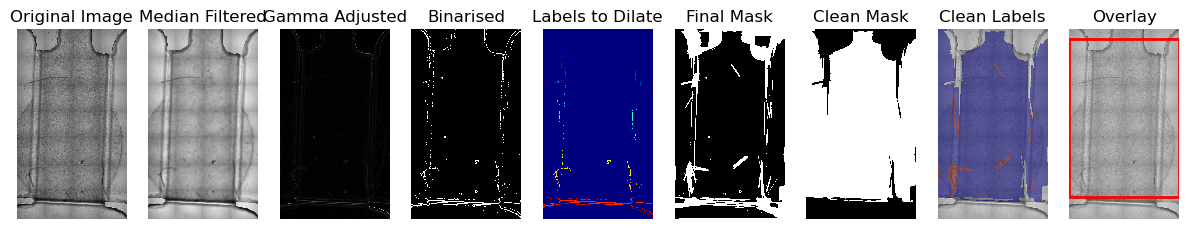

In [18]:
fig, ax = plt.subplots(ncols=9, figsize=(15,5))
titles = ['Original Image', 'Median Filtered', "Gamma Adjusted", 'Binarised', 'Labels to Dilate', 'Final Mask', "Clean Mask", "Clean Labels", "Overlay"]
ax[0].imshow(img, interpolation = "none", cmap='gray')
ax[1].imshow(median_img, interpolation = "none", cmap='gray')
ax[2].imshow(sobel_adjusted, interpolation = "none", cmap='gray')
ax[3].imshow(binary, interpolation = "none", cmap='gray')
ax[4].imshow(labels_to_dilate, interpolation = "none", cmap="jet")
ax[5].imshow(final_mask, interpolation = "none", cmap='gray')
ax[6].imshow(device_mask, interpolation = "none", cmap='gray')

ax[7].imshow(img, alpha = 0.7, cmap="gray", interpolation = "none")
ax[7].imshow(np.ma.masked_where(device_mask == 0, final_mask), cmap="jet", alpha=0.5, interpolation="none")
ax[8].imshow(img, alpha = 0.7, cmap="gray", interpolation = "none")
ax[8].plot(
    np.r_[corners[:, 0], corners[0, 0]],
    np.r_[corners[:, 1], corners[0, 1]],
    "-r", linewidth=2
)
for i, axis in enumerate(ax):
    ax[i].axis('off')
    ax[i].set_title(titles[i])
plt.savefig("device_segmentation_conventional_methods_output_{}.pdf".format(j), transparent=True)

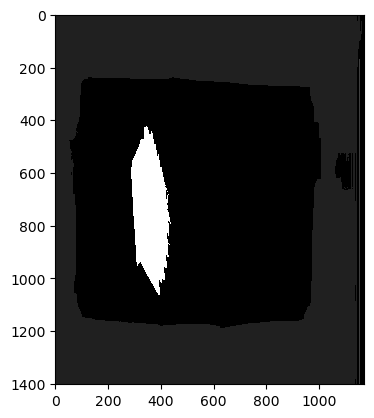

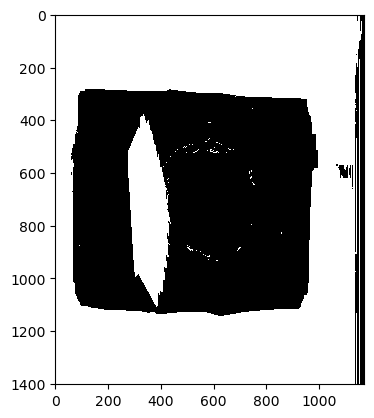

In [24]:
labels = label(final_mask)

data = regionprops_table(labels, final_mask, properties=("label", "area", "eccentricity"))  
condition = (data['area'] > 1000)  & (data['eccentricity'] > 0.3)
labels_to_dilate = util.map_array(labels, data['label'], data['label'] * condition)

plt.imshow(labels_to_dilate, cmap='gray', interpolation='none')
plt.show()

dilated_output = np.zeros_like(labels, dtype=np.uint8)

for region in regionprops(labels_to_dilate):
    region_label = region.label
    mask = labels_to_dilate == region_label
    angle_to_rotate = signed_orientation(region)
    selem = np.zeros((91, 91), dtype=bool)
    selem[35, :] = 1
    rotated_selem = rotate(selem.astype(float), angle=90 + angle_to_rotate, reshape=False, order=0) > 0.5
    dilated = binary_dilation(mask, structure=rotated_selem)
    dilated_output[dilated] = 255
final_mask = np.logical_or(dilated_output, binary)
plt.imshow(final_mask, cmap='gray', interpolation='none')
plt.show()

C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_564728\3057926035.py:64: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  fm = binary_closing(fm, disk(close_radius))
C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_564728\3057926035.py:67: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  inv = remove_small_objects(inv, min_size=min_inv_object_size)


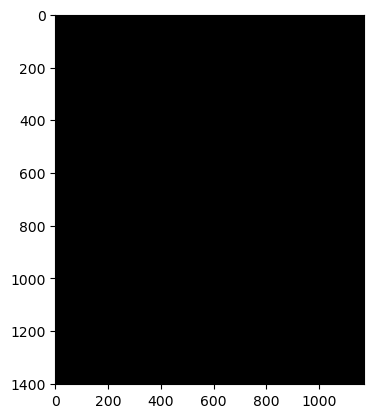

C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_564728\3057926035.py:32: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  er = binary_erosion(inv, disk(erosion_radius))
C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_564728\3057926035.py:102: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  best = remove_small_holes(best, area_threshold=cavity_hole_fill_area)


In [18]:

def _find_seed(inv: np.ndarray, max_radius: int = 25):
    """
    Find a True pixel near the image center to seed the interior.
    Expands a square search window around the center until it finds a True pixel.
    """
    H, W = inv.shape
    cy, cx = H // 2, W // 2
    if inv[cy, cx]:
        return (cy, cx)

    for r in range(1, max_radius + 1):
        y0, y1 = max(0, cy - r), min(H, cy + r + 1)
        x0, x1 = max(0, cx - r), min(W, cx + r + 1)
        window = inv[y0:y1, x0:x1]
        if window.any():
            yy, xx = np.argwhere(window)[0]
            return (y0 + int(yy), x0 + int(xx))

    return None


def cavity_from_inv_bottleneck(inv: np.ndarray, erosion_radius: int) -> np.ndarray | None:
    """
    Break narrow connections by eroding `inv`, pick the eroded component containing a center seed,
    then reconstruct (dilate) it back under the original inv mask.
    """
    inv = inv.astype(bool)
    seed = _find_seed(inv)
    if seed is None:
        return None

    er = binary_erosion(inv, disk(erosion_radius))
    if not er.any():
        return None

    lab = label(er)
    seed_label = lab[seed[0], seed[1]]
    if seed_label == 0:
        # seed got erased away; give up for this radius
        return None

    marker = (lab == seed_label).astype(np.uint8)
    mask = inv.astype(np.uint8)

    # reconstruct by dilation: grow marker back but only where mask allows
    rec = reconstruction(marker, mask, method="dilation") > 0
    return rec


def recover_device_cavity(
    final_mask: np.ndarray,
    *,
    # optional: bridge tiny breaks in final_mask
    do_close: bool = True,
    close_radius: int = 2,
    # clean specks
    min_inv_object_size: int = 5000,
    # if clear_border works, we use it; if not, we fall back to bottleneck reconstruction
    bottleneck_radii: tuple[int, ...] = (2, 3, 4, 5, 6),
    cavity_hole_fill_area: int = 100000,
) -> np.ndarray:
    fm = final_mask.astype(bool)
    if do_close:
        fm = binary_closing(fm, disk(close_radius))

    inv = ~fm
    inv = remove_small_objects(inv, min_size=min_inv_object_size)

    # Attempt 1: clear_border + largest component
    inv_noborder = clear_border(inv)
    plt.imshow(inv_noborder, cmap='gray', interpolation='none')
    plt.show()
    lab = label(inv_noborder)

    if lab.max() > 0:
        props = regionprops(lab)
        largest = max(props, key=lambda p: p.area).label
        cavity = (lab == largest)
        cavity = remove_small_holes(cavity, area_threshold=cavity_hole_fill_area)
        plt.imshow(cavity, cmap='gray', interpolation='none')
        plt.show()
        return cavity

    # Attempt 2 (fallback): bottleneck reconstruction (handles fractured borders)
    best = None
    best_area = -1
    for r in bottleneck_radii:
        cav = cavity_from_inv_bottleneck(inv, erosion_radius=r)
        if cav is None or not cav.any():
            continue
        area = int(cav.sum())
        if area > best_area:
            best_area = area
            best = cav

    if best is None:
        raise RuntimeError(
            "Could not recover interior cavity. Try increasing close_radius, "
            "lowering min_inv_object_size, or extending bottleneck_radii."
        )

    best = remove_small_holes(best, area_threshold=cavity_hole_fill_area)
    return best


# ---- your pipeline produced:
# final_mask = np.logical_or(dilated_output, binary)

# final_mask = np.logical_or(dilated_output, binary).astype(bool)

device_mask = recover_device_cavity(
    final_mask,
    do_close=True,
    close_radius=2,                  # try 1..4
    min_inv_object_size=5000,
    bottleneck_radii=(2, 3, 4, 5, 6),# increase if leaks are wider
    cavity_hole_fill_area=100000
)

corners = central_rect_from_mask(device_mask, angle_deg=0.0, width_frac=0.92, min_run_frac=0.25)


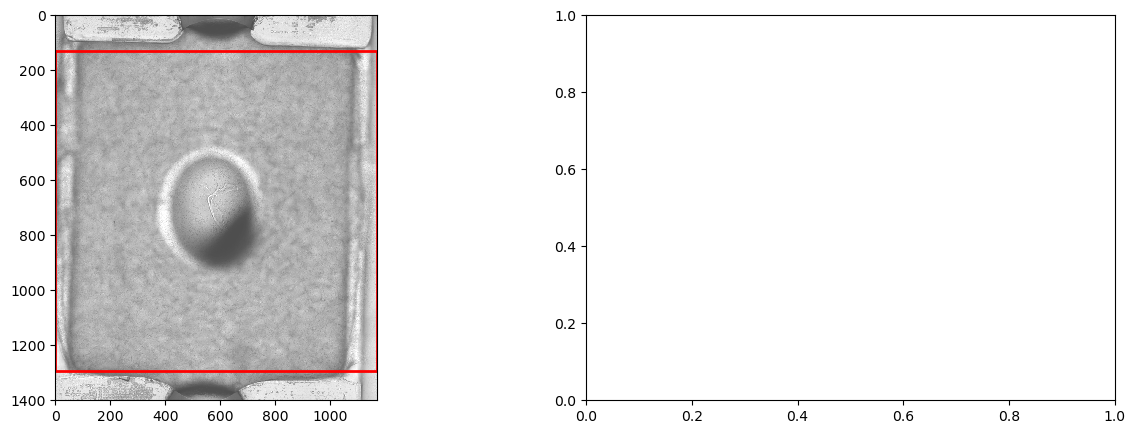

In [17]:
fig, ax = plt.subplots(ncols=2, figsize=(15,5))
ax[0].imshow(img, alpha = 0.7, cmap="gray", interpolation = "none")
ax[0].plot(
    np.r_[corners[:, 0], corners[0, 0]],
    np.r_[corners[:, 1], corners[0, 1]],
    "-r", linewidth=2
)